# **Proyek Analisis Data: Bike Sharing**
- **Nama:** Galang Dava Ramadhan
- **Email:** galangdavaa@gmail.com
- **ID Dicoding:** lxng_vr

## **Menentukan Pertanyaan Bisnis**

- Bagaimana pola penggunaan sepeda harian dan mingguan, khususnya perbedaan jumlah penyewaan antara weekday dan weekend?
- Bagaimana perbedaan perilaku antara pengguna registered dan casual?
- Bagaimana pengaruh musim terhadap jumlah penyewaan sepeda?
- Bagaimana perbedaan penggunaan sepeda pada hari kerja dibanding hari libur?
- Bagaimana kondisi cuaca memengaruhi jumlah penyewaan?
- Bagaimana pola penggunaan sepeda berdasarkan jam dalam sehari (jam sibuk vs jam sepi)?
- Bagaimana perbedaan jumlah penyewaan antara hari kerja dan hari libur pada level jam?


## **Import Semua Packages/Library yang Digunakan**

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Data Wrangling**

### **Gathering Data**

In [86]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [87]:
# Load data day (Penggunaan penyewaan sepeda per hari)

day_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [88]:
# Load data hour (Penggunaan penyewaan sepeda per jam)

hour_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset tersebut berisi informasi penggunaan sepeda harian dan per jam, lengkap dengan faktor waktu, cuaca, dan tipe pengguna.
- Data ini dapat digunakan untuk analisis pola waktu (harian, mingguan, musiman) dan faktor lingkungan (suhu, kelembaban, cuaca).

### **Assessing Data**

#### **1. Tabel Day**

In [89]:
#Informasi dalam tabel 'day'
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [90]:
# Memastikan tidak adanya missing value pada tabel 'day'
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [91]:
# Cek duplicate data tabel 'day'
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [92]:
# Cek paramter statistik tabel 'day'
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Tabel 'day' tidak memiliki data yang kosong (*missing value*) dan data duplikat (*duplicate data*) pada seluruh kolomnya.
- Kolom 'dteday' perlu diubah tipenya dari *object* menjadi *datetime* agar terbaca sebagai format tanggal.
- Jumlah baris data perkolom konsisten di angka 731.
- Rata-rata penyewaan sepeda dalam satu hari adalah sekitar 4.504 unit, dengan angka tertinggi mencapai 8.714 unit.
- Rata-rata kelembapan udara berada di angka 0,62 (62%) dan kecepatan angin di angka 0,19, yang menunjukkan kondisi lingkungan cukup stabil selama periode tersebut.
- Pengguna terdaftar (*registered*) memberikan kontribusi yang jauh lebih besar (rata-rata 3.656 per hari) dibandingkan pengguna biasa (*casual*) yang rata-ratanya hanya 848 per hari.
- Terdapat Keanehan Nilai (Invalid/Inaccurate) pada kolom hum (kelembapan), ada nilai minimum 0.0. Secara fisik, kelembapan 0% di ruang terbuka sangat tidak normal dan menunjukkan adanya kerusakan pada sensor. Data ini akan dihilangkan pada tahap pemrosesan.
- Terindikasinya Outlier pada kolom casual (min: 2, max: 3410) dan cnt (min: 22, max: 8714) terlihat adanya rentang nilai yang sangat luas. Selisih besar antara nilai kuartil atas (75%) dan nilai maksimum menandakan adanya outlier. Akan tetapi, outlier ini adalah kejadian alami (*natural outlier*) seperti peningkatan sewa selama liburan atau penurunan tajam saat cuaca buruk, sehingga data tidak akan dimodifikasi atau dihapus agar informasi penting tetap ada.


#### **2. Tabel Hour**

In [93]:
# Informasi tabel 'hour'
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [94]:
# Cek missing values tabel 'hour'
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [95]:
# Cek duplicate data tabel 'hour'
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [96]:
# Cek deskripsi statistik tabel 'hour'
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tabel 'hour' tidak memiliki data yang kosong (*missing value*) dan data duplikat (*duplicate data*) pada seluruh kolomnya.
- Kolom 'dteday' perlu diubah tipenya dari *object* menjadi *datetime* agar terbaca sebagai format tanggal.
- Jumlah baris data perkolom konsisten di angka 17.379.
- Rata-rata penyewaan sepeda per jam adalah sekitar 189 unit, namun terdapat fluktuasi yang sangat besar dengan angka maksimal mencapai 977 unit dalam satu jam.
- Pengguna terdaftar (*registered*) mendominasi penggunaan setiap jamnya dengan rata-rata 153 unit, jauh lebih tinggi dibandingkan pengguna biasa (*casual*) yang hanya rata-rata 35 unit.
- Sama halnya dengan tabel 'day', Di tabel 'hour' ini juga terdapat Keanehan Nilai (Invalid/Inaccurate) pada kolom hum (kelembapan), ada nilai minimum 0.0. Secara fisik, kelembapan 0% di ruang terbuka sangat tidak normal dan menunjukkan adanya kerusakan pada sensor. Data ini akan dihilangkan pada tahap pemrosesan.
- Dan juga, Terindikasinya Outlier pada kolom casual (min: 2, max: 3410) dan cnt (min: 22, max: 8714) terlihat adanya rentang nilai yang sangat luas. Selisih besar antara nilai kuartil atas (75%) dan nilai maksimum menandakan adanya outlier. Akan tetapi, outlier ini adalah kejadian alami (*natural outlier*) seperti peningkatan sewa selama liburan atau penurunan tajam saat cuaca buruk, sehingga data tidak akan dimodifikasi atau dihapus agar informasi penting tetap ada.

### **Cleaning Data**

In [97]:
# Membetulkan tipedata column dteday pada tabel 'day' dan 'hour'

datetime_columns = ["dteday"]

for column in datetime_columns:
  day_df[column] = pd.to_datetime(day_df[column])
  hour_df[column] = pd.to_datetime(hour_df[column])

In [98]:
# Cek kembali tipedata setelah dibetulkan

day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [99]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [100]:
# Mengecek jumlah baris dengan nilai kelembapan (hum) 0
print("Jumlah baris dengan hum 0.0 pada day_df:", (day_df['hum'] == 0).sum())
print("Jumlah baris dengan hum 0.0 pada hour_df:", (hour_df['hum'] == 0).sum())

# Membersihkan dengan Menghapus baris yang nilai kelembapannya 0
day_df = day_df[day_df['hum'] > 0]
hour_df = hour_df[hour_df['hum'] > 0]

Jumlah baris dengan hum 0.0 pada day_df: 1
Jumlah baris dengan hum 0.0 pada hour_df: 22


In [101]:
# cek kembali nilai humidity pada tabel 'day' dan 'hour'
day_df.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,366.406849,2012-01-01 09:45:51.780822016,2.498630,0.501370,6.524658,0.028767,2.995890,0.683562,1.393151,0.495530,0.474475,0.628754,0.190388,849.275342,3660.390411,4509.665753
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000
25%,184.250000,2011-07-03 06:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.336875,0.337794,0.520521,0.134950,316.250000,2502.250000,3169.750000
50%,366.500000,2012-01-01 12:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.499167,0.487364,0.627083,0.180971,717.000000,3664.500000,4548.500000
75%,548.750000,2012-07-01 18:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655625,0.608916,0.730313,0.233207,1096.500000,4783.250000,5966.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.023699,NaN,1.110184,0.500341,3.451815,0.167266,2.005817,0.465405,0.542015,0.183134,0.163040,0.140614,0.077506,686.449738,1557.149836,1933.194931


In [102]:
hour_df.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17357.000000,17357,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000
mean,8699.034107,2012-01-02 13:12:48.035950848,2.503543,0.503198,6.542260,11.545889,0.028807,3.002420,0.682318,1.423403,0.497124,0.475889,0.628024,0.190007,35.718788,153.948551,189.667339
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.080000,0.000000,0.000000,0.000000,1.000000
25%,4362.000000,2011-07-05 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8701.000000,2012-01-03 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,116.000000,142.000000
75%,13040.000000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5013.782462,NaN,1.106327,0.500004,3.438645,6.914537,0.167268,2.006728,0.465588,0.637492,0.192635,0.171921,0.191754,0.122342,49.321693,151.382189,181.409297


**Insight:**
- Kolom 'dteday' pada tabel 'day' dan 'hour' telah berhasil diubah menjadi tipe datetime agar format tanggal terbaca dengan benar oleh sistem.
- Jumlah baris menurun sedikit tetapi signifikan secara kualitas: Tabel 'day_df' sekarang terdiri dari 730 baris (dari 731), dan 'hour_df' memiliki 17.357 baris (dari 17.379). Disini kita tidak kehilangan banyak informasi, tetapi kita sukses menghapus data yang bisa merusak analisis.
- Nilai Minimum yang lebih normal: Jika diperhatikan hasil describe() yang terbaru, nilai minimum pada kolom hum tidak lagi 0.0, tetapi telah berpindah ke angka yang jauh lebih logis secara fisik (sekitar 0.18 atau setara dengan 18% kelembapan pada tabel 'day_df' dan sekitar 0.08 atau setara dengan 8% kelembapan pada tabel 'hour_df').


### **Save Cleaned Dataset**

In [103]:
day_df.to_csv("day_cleaned.csv", index=False)
hour_df.to_csv("hour_cleaned.csv", index=False)

print("Dataset berhasil disimpan sebagai 'day_cleaned.csv' dan 'hour_cleaned.csv'")

Dataset berhasil disimpan sebagai 'day_cleaned.csv' dan 'hour_cleaned.csv'


## **Exploratory Data Analysis (EDA)**

#### **1. Univariate Analysis**

In [104]:
# Menyiapkan kolom numerik yang akan dianalisis
numerik_cols = ['temp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

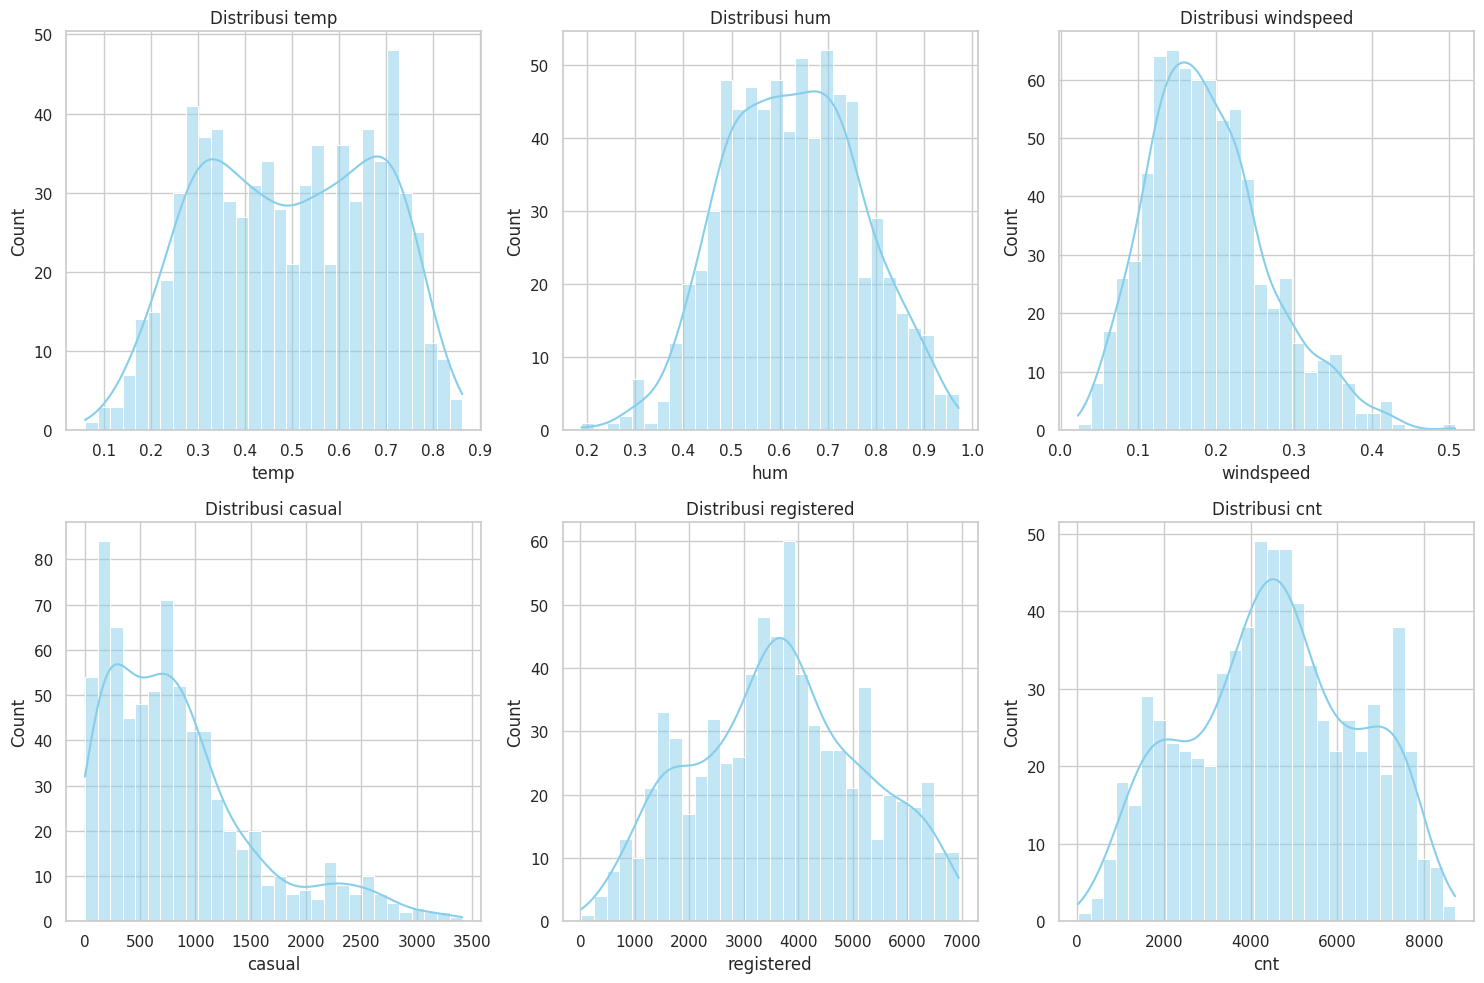

In [105]:
# Distribusi Data (Histogram)
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerik_cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(day_df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

**Insight:**
- Grafik Normal/Simetris: Variabel hum (kelembapan) dan pengguna terdaftar (registered) menunjukkan distribusi yang cukup normal. Total penyewaan (cnt) juga tersebar dengan baik, meskipun menunjukkan dua puncak (bimodal), yaitu di sekitar 4.000 dan 7.000-an.

- Condong ke Kanan (Right-Skewed): Variabel kecepatan angin (windspeed) dan casual (pengguna biasa) sangat miring ke kanan. Dengan kata lain, kecepatan angin biasanya berada pada tingkat rendah hingga menengah, dan jumlah penyewa santai di sebagian besar hari cenderung sedikit (meskipun beberapa hari tertentu mengalami lonjakan yang signifikan).

- Variabel suhu (temp) terdistribusi secara relatif merata dengan pertanda dua puncak (suhu dingin dan suhu hangat yang menunjukkan perubahan musim).


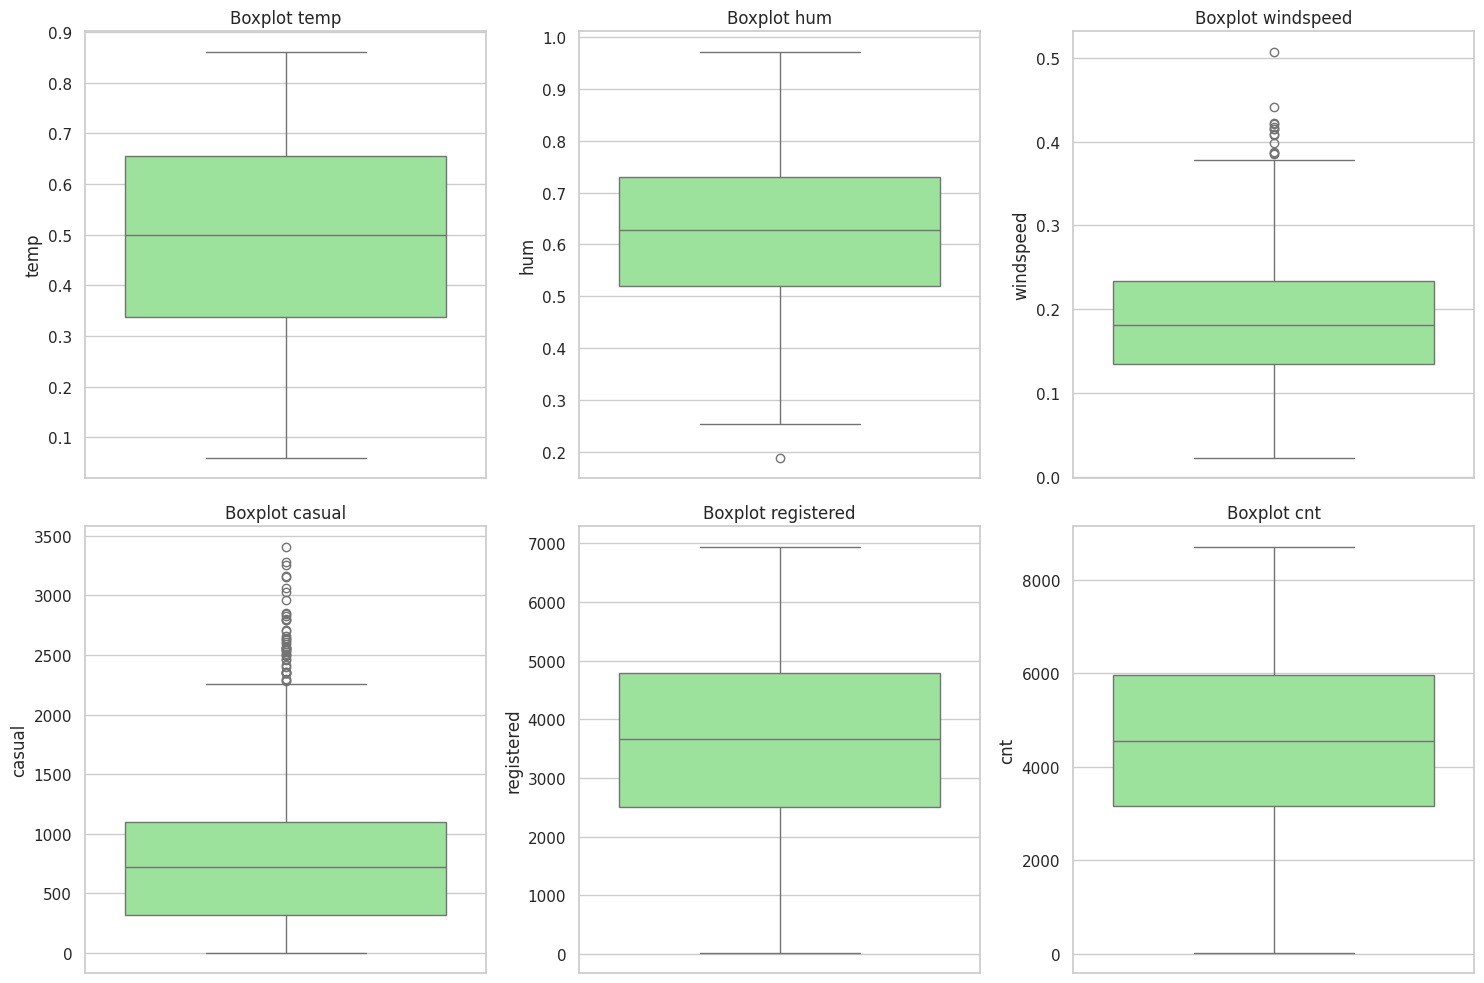

In [106]:
# Deteksi Outlier (Boxplot)
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerik_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=day_df[col], color='lightgreen')
    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

**Insight:**
1. Grafik Tanpa Outlier: Variabel temp, registered, dan cnt sangat bersih dan tidak memiliki outlier. Seluruh datanya masih berada di dalam rentang whisker (batas atas dan batas bawah).

2. Grafik Terdapat Outlier:
* casual: Terdapat banyak outlier di atas batas atas (titik-titik di atas angka 2.200). Ini menunjukkan ada hari-hari tertentu di mana penyewa biasa (casual) melonjak sangat tinggi (kemungkinan besar saat hari libur atau akhir pekan).

* windspeed: Terdapat beberapa outlier di atas batas atas, yang mengindikasikan ada beberapa hari dengan kondisi angin yang sangat kencang/badai.

* hum: Terdapat satu outlier di bawah batas bawah (sekitar angka 0.2). Ini menunjukkan hari dengan tingkat kelembapan udara yang sangat kering, namun angkanya sudah logis (tidak 0.0 lagi karena sudah dibersihkan sebelumnya).

#### **2. Bivariate Analysis**

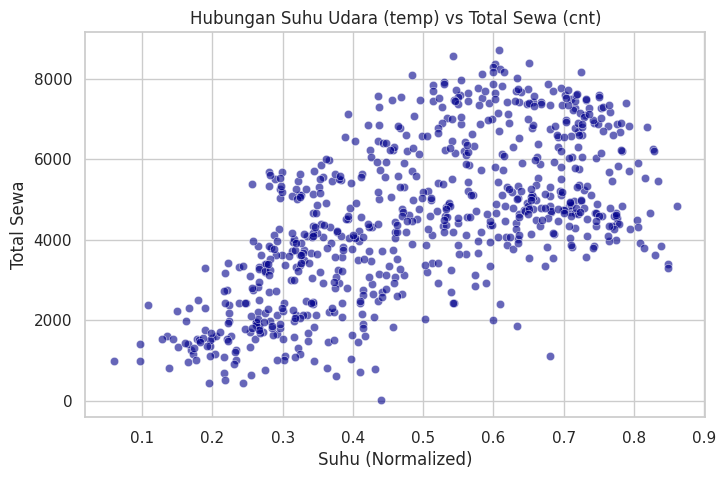

In [107]:
# Scatter Plot (Hubungan Suhu dan Jumlah Sewa)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='temp', y='cnt', data=day_df, alpha=0.6, color='darkblue')
plt.title('Hubungan Suhu Udara (temp) vs Total Sewa (cnt)')
plt.xlabel('Suhu (Normalized)')
plt.ylabel('Total Sewa')
plt.show()

**Insight:**
*Hubungan Suhu Udara (temp) dengan Total Sewa (cnt)*
* Melalui scatter plot, terlihat jelas adanya korelasi positif yang cukup kuat antara suhu udara dan jumlah penyewaan sepeda.
* Tren menunjukkan bahwa ketika suhu semakin hangat (nilai pada sumbu-x bergerak ke kanan menuju 0.6 - 0.7), jumlah sepeda yang disewa semakin meningkat secara signifikan.
* Namun, pada suhu yang terik/sangat panas (mendekati nilai 0.8 - 0.9), jumlah penyewaan tampak sedikit melandai atau menurun, menandakan pengguna lebih menyukai suhu hangat yang pas untuk bersepeda.

/tmp/ipykernel_2077/1554806313.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='cnt', data=day_df, ax=ax[0], palette='Set2')
/tmp/ipykernel_2077/1554806313.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weathersit', y='cnt', data=day_df, ax=ax[1], palette='Set1')


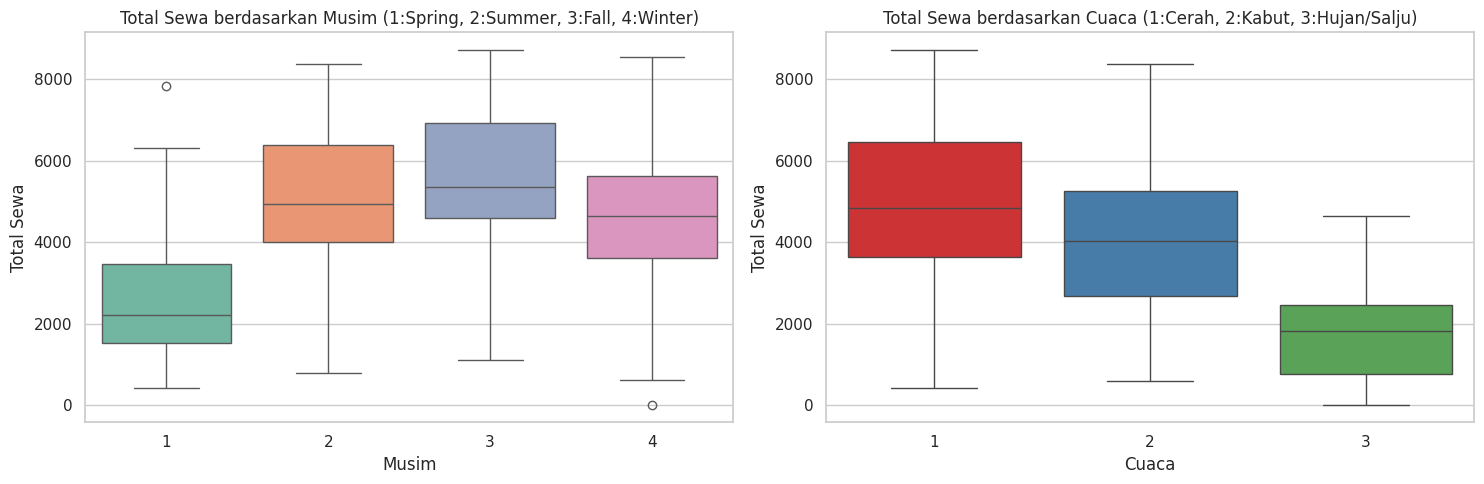

In [108]:
# Boxplot Kategori (Sewa berdasarkan Musim dan Cuaca)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x='season', y='cnt', data=day_df, ax=ax[0], palette='Set2')
ax[0].set_title('Total Sewa berdasarkan Musim (1:Spring, 2:Summer, 3:Fall, 4:Winter)')
ax[0].set_xlabel('Musim')
ax[0].set_ylabel('Total Sewa')

sns.boxplot(x='weathersit', y='cnt', data=day_df, ax=ax[1], palette='Set1')
ax[1].set_title('Total Sewa berdasarkan Cuaca (1:Cerah, 2:Kabut, 3:Hujan/Salju)')
ax[1].set_xlabel('Cuaca')
ax[1].set_ylabel('Total Sewa')

plt.tight_layout()
plt.show()

**Insight**
1. **Hubungan Musim (*season*) dengan Total Sewa (cnt)**
* Dari boxplot pertama, penyewaan paling tinggi terjadi pada musim ke-3 (Fall/Gugur) yang memiliki nilai median tertinggi, disusul oleh musim ke-2 (Summer/Panas).
* Musim ke-1 (Spring/Semi) menunjukkan angka penyewaan yang paling rendah. Hal ini sangat logis karena secara iklim, awal musim semi masih membawa suhu dingin sisa dari musim dingin (Winter), sehingga minat bersepeda belum terlalu tinggi.
* Terdapat outlier atas pada Musim 1 (penyewaan melonjak hingga hampir 8.000), yang bisa jadi merupakan hari libur/festival dengan cuaca musim semi yang tiba-tiba sangat cerah. Sebaliknya, terdapat outlier bawah pada Musim 4 (Winter) di mana penyewaan nyaris menyentuh angka 0, kemungkinan besar akibat kondisi cuaca ekstrem seperti badai salju parah.


2. **Hubungan Kondisi Cuaca (*weathersit*) dengan Total Sewa (cnt)**
* Boxplot kedua membuktikan bahwa cuaca adalah faktor penentu utama. Kondisi cuaca ke-1 (Cerah/Sedikit Berawan) menghasilkan distribusi penyewaan tertinggi.
* Semakin buruk cuaca, semakin turun pula minat pengguna. Kondisi cuaca ke-2 (Kabut/Mendung) menurunkan median sewa secara cukup signifikan.
* Pada kondisi cuaca ke-3 (Hujan/Salju ringan), jumlah penyewaan anjlok drastis ke titik terendahnya.

#### **3. Multivariate Analysis**

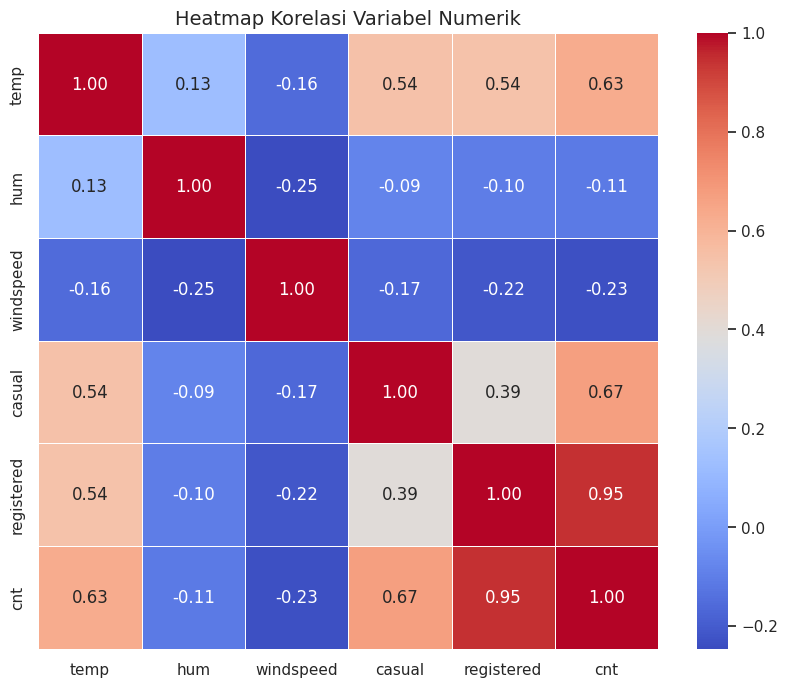

In [109]:
# Heatmap Korelasi antar variabel numerik
plt.figure(figsize=(10, 8))
correlation_matrix = day_df[numerik_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Numerik', fontsize=14)
plt.show()

**Insight:**
* Penyumbang Terbesar (Korelasi Sangat Kuat): Variabel registered memiliki korelasi positif yang hampir sempurna (0.95) terhadap cnt. Hal ini membuktikan bahwa pelanggan terdaftar (registered users) adalah tulang punggung utama yang mendominasi total penyewaan harian. Pengguna casual juga memiliki korelasi positif yang kuat (0.67), namun tetap jauh di bawah pelanggan terdaftar.

* Faktor Lingkungan Paling Berpengaruh: Di antara semua variabel cuaca, suhu udara (temp) memiliki korelasi positif yang paling kuat terhadap total penyewaan, yaitu sebesar 0.63. Ini sejalan dengan analisis bivariate, di mana suhu yang lebih hangat sangat efektif memicu peningkatan minat bersepeda.

* Faktor Penurun Minat (Korelasi Negatif): Variabel kecepatan angin (windspeed) memiliki korelasi negatif sebesar -0.23, dan kelembapan (hum) memiliki korelasi negatif sebesar -0.11 terhadap cnt. Nilai negatif ini menunjukkan hubungan terbalik: semakin kencang angin berhembus atau semakin lembap/pengap udara, minat pengguna untuk menyewa sepeda cenderung menurun.

## **Explanatory Data Analysis**

#### **1. Tabel 'Day'**

In [110]:
# Lihat rangkuman statistik deskriptif tabel 'day'

day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,366.406849,2012-01-01 09:45:51.780822016,2.498630,0.501370,6.524658,0.028767,2.995890,0.683562,1.393151,0.495530,0.474475,0.628754,0.190388,849.275342,3660.390411,4509.665753
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000
25%,184.250000,2011-07-03 06:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.336875,0.337794,0.520521,0.134950,316.250000,2502.250000,3169.750000
50%,366.500000,2012-01-01 12:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.499167,0.487364,0.627083,0.180971,717.000000,3664.500000,4548.500000
75%,548.750000,2012-07-01 18:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655625,0.608916,0.730313,0.233207,1096.500000,4783.250000,5966.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.023699,NaN,1.110184,0.500341,3.451815,0.167266,2.005817,0.465405,0.542015,0.183134,0.163040,0.140614,0.077506,686.449738,1557.149836,1933.194931


In [111]:
# Hitung total penyewaan per hari (0=Sunday, 6=Saturday) berdasarkan file README.txt
day_totals = day_df.groupby('weekday')['cnt'].sum().reset_index()

# Mapping angka ke nama hari
day_names = {0:'Sunday', 1:'Monday', 2:'Tuesday', 3:'Wednesday', 4:'Thursday', 5:'Friday', 6:'Saturday'}
day_totals['weekday'] = day_totals['weekday'].map(day_names)

print(day_totals)

     weekday     cnt
0     Sunday  444027
1     Monday  455503
2    Tuesday  469109
3  Wednesday  473048
4   Thursday  484772
5     Friday  487790
6   Saturday  477807


In [112]:
# Hari dengan total penyewaan terbanyak
max_day = day_totals.loc[day_totals['cnt'].idxmax()]

# Hari dengan total penyewaan terkecil
min_day = day_totals.loc[day_totals['cnt'].idxmin()]

print("Hari dengan total terbanyak:", max_day['weekday'], "-", max_day['cnt'])
print("Hari dengan total terkecil:", min_day['weekday'], "-", min_day['cnt'])


Hari dengan total terbanyak: Friday - 487790
Hari dengan total terkecil: Sunday - 444027


In [113]:
# Perbandingan penyewaan sepeda Workingday vs Non-Workingday
weekday_mean = day_df.groupby('workingday').agg({'cnt':'mean'}).reset_index()
print("\n Rata-rata Penyewaan: Workingday vs Non-Workingday")
print(weekday_mean)


 Rata-rata Penyewaan: Workingday vs Non-Workingday
   workingday          cnt
0           0  4330.168831
1           1  4592.759519


In [114]:
# Distribusi Casual vs Registered (total)
casual_registered = day_df[['casual','registered']].sum()
print("\nTotal Casual vs Registered")
print(casual_registered)


Total Casual vs Registered
casual         619971
registered    2672085
dtype: int64


In [115]:
# Seasonal Trend Analysis (rata-rata per musim per tahun)
season_year = day_df.groupby(['season','yr']).agg({'cnt':'mean'}).reset_index()

# Mapping season ke nama musim
season_map = {
    1:'Spring',
    2:'Summer',
    3:'Fall',
    4:'Winter'
    }
season_year['season'] = season_year['season'].map(season_map)

# Mapping yr ke tahun sebenarnya
year_map = {
    0:2011,
    1:2012
    }
season_year['yr'] = season_year['yr'].map(year_map)

print("\n Rata-rata Penyewaan per Musim per Tahun")
print(season_year)


 Rata-rata Penyewaan per Musim per Tahun
   season    yr          cnt
0  Spring  2011  1678.393258
1  Spring  2012  3531.296703
2  Summer  2011  3775.173913
3  Summer  2012  6209.489130
4    Fall  2011  4464.361702
5    Fall  2012  6824.244681
6  Winter  2011  3664.460674
7  Winter  2012  5791.865169


In [116]:
# Weather Impact (rata-rata per kondisi cuaca)
weather_mean = day_df.groupby('weathersit').agg({'cnt':'mean'}).reset_index()

# Mapping kode cuaca ke deskripsi
weather_map = {
    1: 'Clear / Few clouds / Partly cloudy',
    2: 'Mist / Cloudy / Broken clouds',
    3: 'Light Snow / Light Rain + Thunderstorm',
    4: 'Heavy Rain / Snow + Fog'
}
weather_mean['weathersit'] = weather_mean['weathersit'].map(weather_map)

print("\n Rata-rata Penyewaan per Kondisi Cuaca")
print(weather_mean)


 Rata-rata Penyewaan per Kondisi Cuaca
                               weathersit          cnt
0      Clear / Few clouds / Partly cloudy  4876.786177
1           Mist / Cloudy / Broken clouds  4035.862348
2  Light Snow / Light Rain + Thunderstorm  1862.300000


**Insight:**
- Hari dengan total penyewaan terbanyak tercatat pada Hari Jum'at **(487.790 penyewaan)**, sedangkan yang paling sedikit pada Hari Minggu **(444.027 penyewaan)**, namun selain itu juga hari Sabtu ternyata lebih tinggi dibanding Senin, menunjukkan weekend tidak selalu lebih rendah dari weekday.
- Pengguna yang telah mendaftar sebagai pelanggan tetap *(**registered**)* jauh lebih dominan dibanding pengguna yang belum mendaftar *(**casual**)*.
- Musim panas *(**Summer**)* dan gugur *(**Fall**)* memiliki rata-rata penyewaan tertinggi di kedua tahun **(2011–2012)**, sementara musim dingin *(**Winter**)* selalu paling rendah, menegaskan adanya pola musiman yang kuat.  
- Hari kerja **(workingday=1)** memiliki rata-rata penyewaan lebih tinggi dibanding hari libur **(workingday=0)**.  
- Kondisi cuaca cerah **(weathersit=1)** menghasilkan rata-rata penyewaan tertinggi, kondisi kabut/berawan **(weathersit=2)** menurunkan sedikit, sedangkan hujan/salju ringan **(weathersit=3)** menurunkan drastis jumlah penyewaan.

#### **2. Tabel 'Hour'**

In [117]:
# Lihat rangkuman statistik deskriptif tabel 'day'

hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17357.000000,17357,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000
mean,8699.034107,2012-01-02 13:12:48.035950848,2.503543,0.503198,6.542260,11.545889,0.028807,3.002420,0.682318,1.423403,0.497124,0.475889,0.628024,0.190007,35.718788,153.948551,189.667339
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.080000,0.000000,0.000000,0.000000,1.000000
25%,4362.000000,2011-07-05 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8701.000000,2012-01-03 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,116.000000,142.000000
75%,13040.000000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5013.782462,NaN,1.106327,0.500004,3.438645,6.914537,0.167268,2.006728,0.465588,0.637492,0.192635,0.171921,0.191754,0.122342,49.321693,151.382189,181.409297


In [118]:
# Pola penggunaan per jam
hourly_mean = hour_df.groupby('hr')['cnt'].mean().reset_index()

print(hourly_mean)

    hr         cnt
0    0   53.968276
1    1   33.419087
2    2   22.900560
3    3   11.727403
4    4    6.352941
5    5   19.913408
6    6   76.132597
7    7  212.305785
8    8  359.444904
9    9  219.578512
10  10  173.884298
11  11  208.414601
12  12  253.617607
13  13  253.993132
14  14  241.263736
15  15  251.559066
16  16  312.382716
17  17  461.932785
18  18  425.983494
19  19  311.874828
20  20  226.288858
21  21  172.513067
22  22  131.469051
23  23   87.914718


In [119]:
# Pola penggunaan per jam berdasarkan workingday
hourly_workingday = hour_df.groupby(['hr','workingday'])['cnt'].mean().reset_index()

print(hourly_workingday)

    hr  workingday         cnt
0    0           0   90.800000
1    0           1   36.854545
2    1           0   69.508696
3    1           1   16.582150
4    2           0   53.171053
5    2           1    8.699588
6    3           0   25.775330
7    3           1    4.942553
8    4           0    8.264317
9    4           1    5.429787
10   5           0    8.689189
11   5           1   24.957490
12   6           0   18.742358
13   6           1  102.682828
14   7           0   43.406926
15   7           1  291.125253
16   8           0  105.653680
17   8           1  477.880808
18   9           0  171.623377
19   9           1  241.957576
20  10           0  255.909091
21  10           1  135.606061
22  11           0  315.316017
23  11           1  158.527273
24  12           0  366.259740
25  12           1  201.157258
26  13           0  372.731602
27  13           1  198.804829
28  14           0  364.645022
29  14           1  183.917505
30  15           0  358.813853
31  15  

**Insight:**
- Rata-rata penyewaan sepeda meningkat tajam pada jam 07–09 pagi dan 17–19 sore, menandakan adanya pola *commuting*.
- Pada hari kerja, pola jam sibuk lebih jelas (puncak pagi & sore), sedangkan pada hari libur pola lebih menyebar sepanjang hari tanpa lonjakan tajam.

##**Data Visualization**

### **Pertanyaan 1:** Bagaimana pola penggunaan sepeda harian dan mingguan, khususnya perbedaan jumlah penyewaan antara weekday dan weekend?

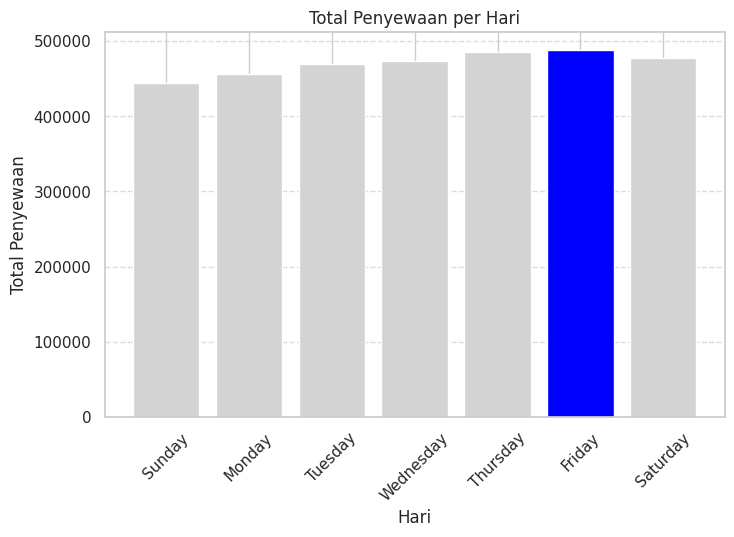

In [120]:
# Eksplanatori perbedaan penyewaan weekday dan weekend
day_totals = day_df.groupby('weekday')['cnt'].sum().reset_index()
day_names = {0:'Sunday', 1:'Monday', 2:'Tuesday', 3:'Wednesday', 4:'Thursday', 5:'Friday', 6:'Saturday'}
day_totals['weekday'] = day_totals['weekday'].map(day_names)

max_value = day_totals['cnt'].max()
colors = ['blue' if val == max_value else 'lightgray' for val in day_totals['cnt']]

plt.figure(figsize=(8,5))
plt.bar(day_totals['weekday'], day_totals['cnt'], color=colors)
plt.title("Total Penyewaan per Hari")
plt.xlabel("Hari")
plt.ylabel("Total Penyewaan")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


**Insight:**
- Pola ini menegaskan bahwa *weekday* cenderung lebih tinggi karena sepeda banyak dipakai untuk *commuting*.
- Hari Jum'at menjadi puncak penggunaan, kemungkinan karena aktivitas kerja dan sosial menjelang akhir pekan.
- Hari Minggu paling rendah, menandakan aktivitas rekreasi tidak seintensif *commuting*.
- Hari Sabtu cukup tinggi, bahkan lebih tinggi dari Senin, menunjukkan adanya segmen pengguna rekreasi yang signifikan.
- Insight ini berarti strategi layanan bisa diarahkan ke *commuting* di *weekday* dan rekreasi di Sabtu.

### **Pertanyaan 2: Bagaimana perbedaan perilaku antara pengguna registered dan casual?**

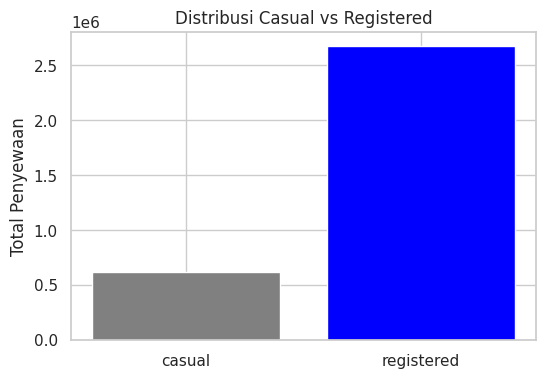

In [121]:
# 2. Casual vs Registered
casual_registered = day_df[['casual','registered']].sum()
plt.figure(figsize=(6,4))
plt.bar(casual_registered.index, casual_registered.values, color=['grey','blue'])
plt.title("Distribusi Casual vs Registered")
plt.ylabel("Total Penyewaan")
plt.show()

**Insight:**
- Dominasi pengguna *registered* menandakan mayoritas pelanggan adalah pengguna tetap yang sudah berkomitmen. Hal ini menunjukkan adanya loyalitas tinggi dari pelanggan *registered*, yang menjadi *backbone* bisnis.
- Sebaliknya, pengguna *casual* masih signifikan, tapi jauh lebih kecil. Ini membuka peluang untuk strategi konversi, misalnya dengan promo, diskon, atau program *membership* agar pelanggan *casual* mau menjadi pelanggan *registered*.
- Insight ini berarti perusahaan bisa mengutamakan retensi *registered* sekaligus akuisisi casual untuk meningkatkan basis pelanggan.

### **Pertanyaan 3: Bagaimana pengaruh musim terhadap jumlah penyewaan sepeda?**

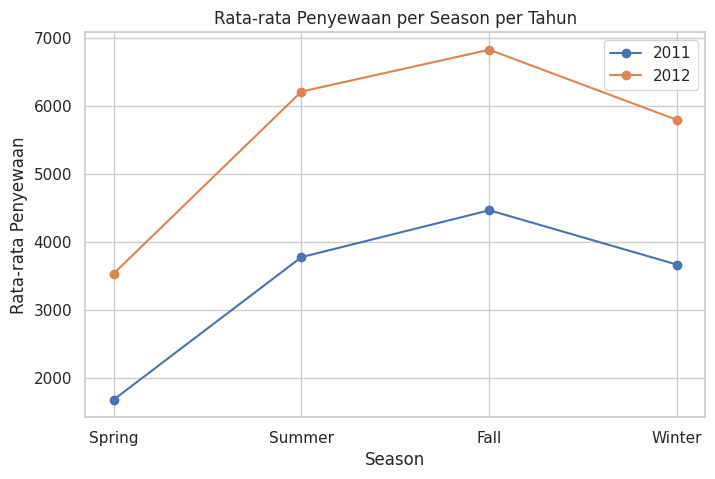

In [122]:
# 3. Seasonal Trend Analysis
season_year = day_df.groupby(['season','yr']).agg({'cnt':'mean'}).reset_index()
season_map = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
year_map = {0:2011, 1:2012}
season_year['season'] = season_year['season'].map(season_map)
season_year['yr'] = season_year['yr'].map(year_map)

plt.figure(figsize=(8,5))
for year in season_year['yr'].unique():
    subset = season_year[season_year['yr']==year]
    plt.plot(subset['season'], subset['cnt'], marker='o', label=str(year))
plt.title("Rata-rata Penyewaan per Season per Tahun")
plt.xlabel("Season")
plt.ylabel("Rata-rata Penyewaan")
plt.legend()
plt.show()

**Insight:**
- Pola musiman yang sangat jelas yaitu Musim Panas *(Summer)* dan Musim Gugur *(Fall)* adalah periode dengan permintaan tertinggi, sedangkan Musim Dingin *(Winter)* selalu rendah. Hal ini menegaskan bahwa faktor musim sangat memengaruhi perilaku pengguna.
- Peningkatan di tahun 2012 dibanding 2011 menunjukkan adanya tren pertumbuhan penggunaan sepeda secara keseluruhan.

Dari Insight ini berarti perusahaan harus:
* Mengantisipasi lonjakan permintaan di Musim Panas atau Gugur *(Summer/Fall)* dengan menambah *supply* sepeda.
- Menghadapi penurunan di Musim Dingin *(Winter)* dengan strategi *pricing*, promosi, atau layanan alternatif.
- Memanfaatkan tren pertumbuhan tahunan untuk memperkuat strategi ekspansi.

### **Pertanyaan 4: Bagaimana perbedaan penggunaan sepeda pada hari kerja dibanding hari libur?**

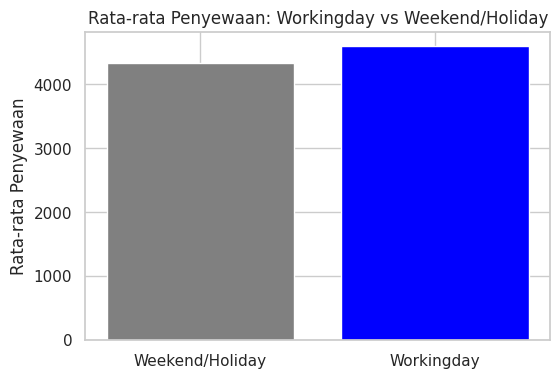

In [123]:
# 4. Workingday vs Non-workingday
weekday_mean = day_df.groupby('workingday')['cnt'].mean().reset_index()
weekday_mean['workingday'] = weekday_mean['workingday'].map({0:'Weekend/Holiday',1:'Workingday'})

plt.figure(figsize=(6,4))
plt.bar(weekday_mean['workingday'], weekday_mean['cnt'], color=['grey','blue'])
plt.title("Rata-rata Penyewaan: Workingday vs Weekend/Holiday")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

**Insight:**
- Pola ini menegaskan bahwa sepeda lebih banyak digunakan sebagai moda transportasi rutin (*commuting*) pada hari kerja.
- Hari libur/weekend lebih rendah, menandakan penggunaan sepeda untuk rekreasi tidak seintensif *commuting*.

Insight ini berarti perusahaan bisa:
- Fokus menyediakan sepeda di lokasi strategis (kantor, kampus, stasiun) untuk mendukung *commuting* di hari kerja.
- Menawarkan program rekreasi atau paket khusus di *weekend* untuk meningkatkan penggunaan di hari libur.

### **Pertanyaan 5: Bagaimana kondisi cuaca memengaruhi jumlah penyewaan sepeda?**

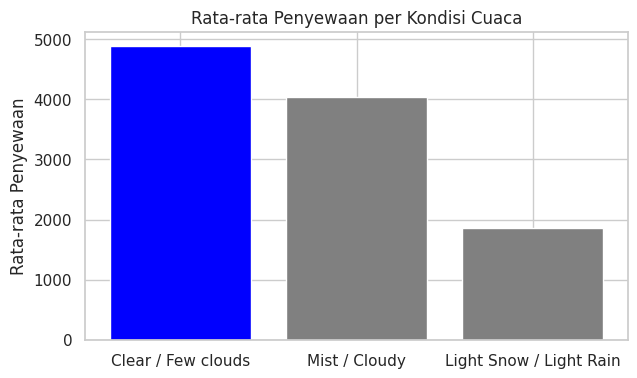

In [124]:
# 5. Weather Impact
weather_mean = day_df.groupby('weathersit')['cnt'].mean().reset_index()
weather_map = {
    1: 'Clear / Few clouds',
    2: 'Mist / Cloudy',
    3: 'Light Snow / Light Rain'
}
weather_mean['weathersit'] = weather_mean['weathersit'].map(weather_map)

plt.figure(figsize=(7,4))
plt.bar(weather_mean['weathersit'], weather_mean['cnt'], color=['blue','grey','grey'])
plt.title("Rata-rata Penyewaan per Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

**Insight:**
- Pola ini menegaskan bahwa cuaca adalah faktor kritis dalam penggunaan sepeda.
- Saat cuaca cerah, pengguna lebih nyaman dan aman untuk bersepeda, sehingga permintaan meningkat.
- Cuaca berkabut/berawan menurunkan sedikit karena visibilitas berkurang, tapi masih memungkinkan aktivitas.
- Cuaca hujan/salju ringan menurunkan drastis karena kondisi jalan licin dan tidak nyaman, sehingga pengguna cenderung menghindari bersepeda.

Dari insight ini berarti perusahaan bisa:
- Mengantisipasi penurunan permintaan saat cuaca buruk dengan mengurangi *supply* sepeda atau menawarkan alternatif layanan.
- Memanfaatkan cuaca cerah untuk kampanye promosi atau event khusus karena permintaan tinggi.
- Mengintegrasikan prediksi cuaca ke dalam sistem perencanaan operasional agar *supply-demand* lebih optimal.

### **Pertanyaan 6: Bagaimana pola penggunaan sepeda berdasarkan jam dalam sehari (jam sibuk vs jam sepi)?**

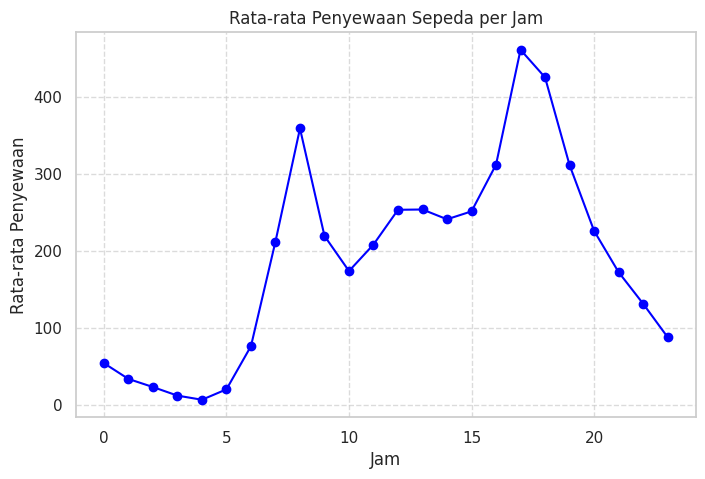

In [125]:
# Pola per jam
plt.figure(figsize=(8,5))
plt.plot(hourly_mean['hr'], hourly_mean['cnt'], marker='o', color='blue')
plt.title("Rata-rata Penyewaan Sepeda per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Insight:**
- Pola ini menegaskan bahwa sepeda digunakan terutama untuk *commuting* yang dapat dilihat pada grafik yaitu puncak pagi saat berangkat kerja/kuliah, dan puncak sore saat pulang.
- Implikasinya: perusahaan harus memastikan ketersediaan sepeda di lokasi strategis (kantor, kampus, stasiun) pada jam sibuk.

### **Pertanyaan 7: Bagaimana perbedaan jumlah penyewaan antara hari kerja dan hari libur pada level jam?**

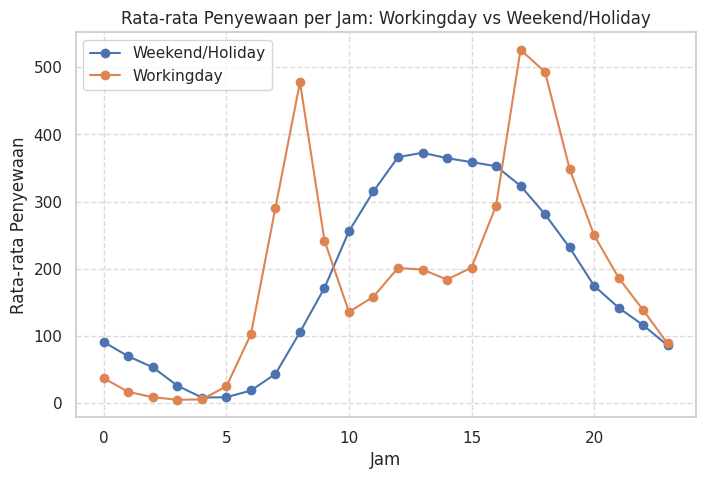

In [126]:
plt.figure(figsize=(8,5))
for wd in hourly_workingday['workingday'].unique():
    subset = hourly_workingday[hourly_workingday['workingday']==wd]
    label = 'Workingday' if wd==1 else 'Weekend/Holiday'
    plt.plot(subset['hr'], subset['cnt'], marker='o', label=label)

plt.title("Rata-rata Penyewaan per Jam: Workingday vs Weekend/Holiday")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Insight:**
- Pada hari kerja, pola jam sibuk sangat jelas (lonjakan pagi & sore).
- Pada hari libur, pola lebih datar yang berarti penggunaan tersebar sepanjang hari, menandakan aktivitas rekreasi.
- Implikasinya: strategi operasional bisa berbeda. Jadi perusahaan dapat fokus *supply commuting* di *weekday*, dan rekreasi di *weekend*.

## **Analisis Lanjutan (Opsional)**

#### **Clustering Analysis**

In [127]:
# Binning (Demand Level pada day.csv)

# Membagi 'cnt' menjadi 3 kategori (Low, Medium, High)
day_df['Demand_Level'] = pd.qcut(day_df['cnt'], q=3, labels=['Low Demand', 'Medium Demand', 'High Demand'])

# Menghitung jumlah hari untuk masing-masing kategori dan menjadikannya DataFrame
demand_counts_df = day_df['Demand_Level'].value_counts().reindex(
    ['Low Demand', 'Medium Demand', 'High Demand']
).reset_index()
demand_counts_df.columns = ['Demand_Level', 'Jumlah_Hari']

print(" Hasil Clustering: Binning (Tingkat Permintaan Harian)")
display(demand_counts_df)

print("\n")

# 2. Manual Groupping (Time of Day pada hour.csv)
def categorize_time(hr):
    if 6 <= hr <= 9:
        return 'Morning Rush (06-09)'
    elif 10 <= hr <= 15:
        return 'Mid-Day (10-15)'
    elif 16 <= hr <= 19:
        return 'Evening Rush (16-19)'
    else:
        return 'Night/Early (20-05)'

# Mengaplikasikan fungsi ke dalam kolom baru
hour_df['Time_Group'] = hour_df['hr'].apply(categorize_time)

# Menghitung rata-rata penyewaan untuk tiap kelompok waktu dan menjadikannya DataFrame
time_group_avg_df = hour_df.groupby('Time_Group')['cnt'].mean().reindex([
    'Morning Rush (06-09)', 'Mid-Day (10-15)', 'Evening Rush (16-19)', 'Night/Early (20-05)'
]).reset_index()
time_group_avg_df.columns = ['Kategori_Waktu', 'Rata_rata_Sewa']

print(" Hasil Clustering: Manual Grouping (Jam Sibuk)")
display(time_group_avg_df) # Akan menampilkan tabel rapi di Colab

 Hasil Clustering: Binning (Tingkat Permintaan Harian)


,Demand_Level,Jumlah_Hari
0,Low Demand,244
1,Medium Demand,243
2,High Demand,243




 Hasil Clustering: Manual Grouping (Jam Sibuk)


,Kategori_Waktu,Rata_rata_Sewa
0,Morning Rush (06-09),216.962440
1,Mid-Day (10-15),230.486133
2,Evening Rush (16-19),378.055975
3,Night/Early (20-05),77.426323


/tmp/ipykernel_2077/2951204903.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2077/2951204903.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


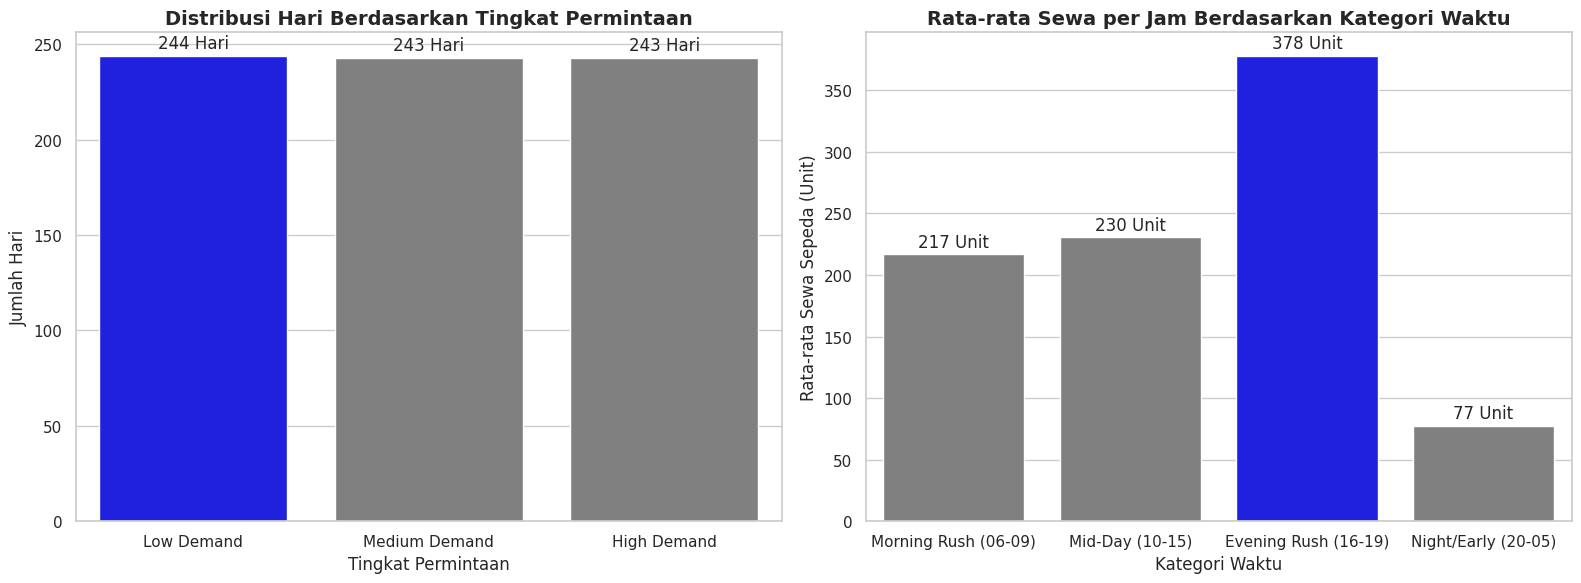

In [128]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

max_demand = demand_counts_df['Jumlah_Hari'].max()
colors_demand = ['blue' if val == max_demand else 'grey' for val in demand_counts_df['Jumlah_Hari']]

sns.barplot(
    x='Demand_Level',
    y='Jumlah_Hari',
    data=demand_counts_df,
    ax=axes[0],
    palette=colors_demand
)
axes[0].set_title('Distribusi Hari Berdasarkan Tingkat Permintaan', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Hari', fontsize=12)
axes[0].set_xlabel('Tingkat Permintaan', fontsize=12)

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f} Hari',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points')

max_time = time_group_avg_df['Rata_rata_Sewa'].max()

colors_time = ['blue' if val == max_time else 'grey' for val in time_group_avg_df['Rata_rata_Sewa']]

sns.barplot(
    x='Kategori_Waktu',
    y='Rata_rata_Sewa',
    data=time_group_avg_df,
    ax=axes[1],
    palette=colors_time
)
axes[1].set_title('Rata-rata Sewa per Jam Berdasarkan Kategori Waktu', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Rata-rata Sewa Sepeda (Unit)', fontsize=12)
axes[1].set_xlabel('Kategori Waktu', fontsize=12)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f} Unit',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

**Tujuan:**
Tujuan utama analisis clustering dalam data ini adalah mempermudah pola penyewaan harian dan jam operasional yang rumit menjadi segmen-segmen yang terorganisir, sehingga perusahaan dapat mengembangkan strategi distribusi armada dan promosi yang lebih terarah dan efektif.

**Insight:**
- Hari dengan tingkat permintaan *Low, Medium,* dan *High* terbagi rata, masing-masing 244 hari (Pada high demand hanya berbeda 1 hari saja, yaitu 243 hari). Ini menunjukkan bisnis berjalan stabil tanpa ketimpangan ekstrem antara hari sepi dan hari sibuk.
- Jam *Evening Rush* (16:00 - 19:59) mencatat penyewaan tertinggi (±378 unit/jam). Mobilitas pulang kerja atau aktivitas sore adalah momen krusial yang menuntut ketersediaan sepeda maksimal.
- Penyewaan di siang hari / *Mid-Day* (± 230 unit/jam) ternyata mengalahkan jam komuter pagi (± 216 unit/jam). Aktivitas seperti makan siang, perjalanan dekat, atau rekreasi turis menyumbang *traffic* yang sangat signifikan.

## **Conclusion**

- **Conclution pertanyaan 1** : Kegiatan komuter mendominasi layanan penyewaan sepeda pada hari kerja (dengan puncak di hari Jumat), tetapi tetap memiliki segmen rekreasi yang signifikan pada hari Sabtu. Dengan demikian, strategi operasional perlu diarahkan untuk memenuhi kebutuhan *commuting* pada hari kerja dan dipindahkan ke area rekreasi saat akhir pekan.
- **Conclution pertanyaan 2** : Pelanggan terdaftar (*registered*) adalah tulang punggung (*backbone*) bisnis yang memberikan pendapatan stabil, sedangkan pengguna biasa (*casual*) merupakan pangsa pasar potensial. Strategi bisnis harus menyeimbangkan antara mempertahankan retensi pelanggan setia dan melakukan kampanye konversi agresif (promo/membership) untuk mengubah pengguna casual menjadi *registered*.
- **Conclution Pertanyaan 3** :Permintaan sewa sepeda dipengaruhi secara signifikan oleh musim (puncak terjadi di Musim Panas/Gugur dan menurun di Musim Dingin), tetapi secara historis menunjukkan tren pertumbuhan tahunan yang positif. Perusahaan harus menerapkan strategi pasokan yang fleksibel yaitu dapat mengoptimalkan armada pada musim puncak dan menerapkan strategi penyesuaian harga atau promosi untuk bertahan di musim sepi.
- **Conclution Pertanyaan 4** :Sepeda umumnya lebih berfungsi sebagai sarana transportasi sehari-hari (*commuting*) daripada sebagai alat untuk rekreasi. Prioritas utama penempatan dan distribusi sepeda harus diarahkan ke lokasi transit strategis (perkantoran, kampus, dan stasiun) pada hari kerja, sembari merancang program khusus untuk mendorong penggunaan di hari libur.
- **Conclution Pertanyaan 5** : Kondisi cuaca adalah penentu kritis terhadap fluktuasi permintaan penyewaan. Mengingat cuaca buruk menurunkan permintaan secara drastis, operasional perusahaan harus responsif dengan mengintegrasikan data prakiraan cuaca untuk efisiensi *supply* armada dan meminimalkan biaya operasional saat cuaca tidak mendukung.
- **Conclution Pertanyaan 6**: Pola pemakaian harian dipengaruhi oleh jam-jam sibuk komuter, yaitu peningkatan pada pagi (jam berangkat) dan sore hari (jam pulang). Keberhasilan operasional harian bergantung pada kepastian ketersediaan sepeda di lokasi strategis pada jendela waktu penting tersebut.
- **Conclution Pertanyaan 7** : Karakteristik penggunaan armada mendorong penerapan dua model operasional yang berbeda, yaitu sistem terpusat selama jam ramai pada hari kerja, dan sistem terdistribusi merata sepanjang hari untuk mendukung kegiatan rekreasi di akhir pekan.
